

# Removing muscle ICA components



In [1]:
!pip install mne

In [2]:
!pip install python-picard

In [94]:
import pandas as pd
import numpy as np
import mne

# Leer archivo
df = pd.read_csv("/content/Filt-Matias.txt", sep="\t")
df.columns = ["Fp1", "Fp2"]

# Obtener los primeros 64 canales del montaje estándar
montage = mne.channels.make_standard_montage("standard_1020")
ch_names = montage.ch_names[:64]

# Crear matriz de ceros (64 canales × muestras)
n_samples = len(df)
data = np.zeros((64, n_samples))

# Buscar dónde están Fp1 y Fp2 dentro de esos 64 canales
idx_fp1 = ch_names.index("Fp1")
idx_fp2 = ch_names.index("Fp2")

# Copiar las señales
data[idx_fp1, :] = df["Fp1"].values
data[idx_fp2, :] = df["Fp2"].values

# Crear objeto Raw
info = mne.create_info(
    ch_names=ch_names,
    sfreq=1000,
    ch_types="eeg"
)

raw = mne.io.RawArray(data, info)

# Asignar el montaje
raw.set_montage(montage)

raw.crop(tmin=20, tmax=100)

raw.pick(picks="eeg", exclude="bads")

# ICA works best with a highpass filter applied
raw.load_data()
raw.filter(l_freq=1.0, h_freq=None)

Creating RawArray with float64 data, n_channels=64, n_times=117600
    Range : 0 ... 117599 =      0.000 ...   117.599 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)



<RawArray | 64 x 80001 (80.0 s), ~39.1 MiB, data loaded>

Run ICA



In [95]:
ica = mne.preprocessing.ICA(
    n_components=2, method="picard", max_iter="auto", random_state=97
)
ica.fit(raw)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 2 components
Fitting ICA took 10.4s.


Method,picard
Fit parameters,max_iter=500
Fit,91 iterations on raw data (80001 samples)
ICA components,2
Available PCA components,64
Channel types,eeg
ICA components marked for exclusion,—


Remove components with postural muscle artifact using ICA



Creating RawArray with float64 data, n_channels=2, n_times=80001
    Range : 20000 ... 100000 =     20.000 ...   100.000 secs
Ready.


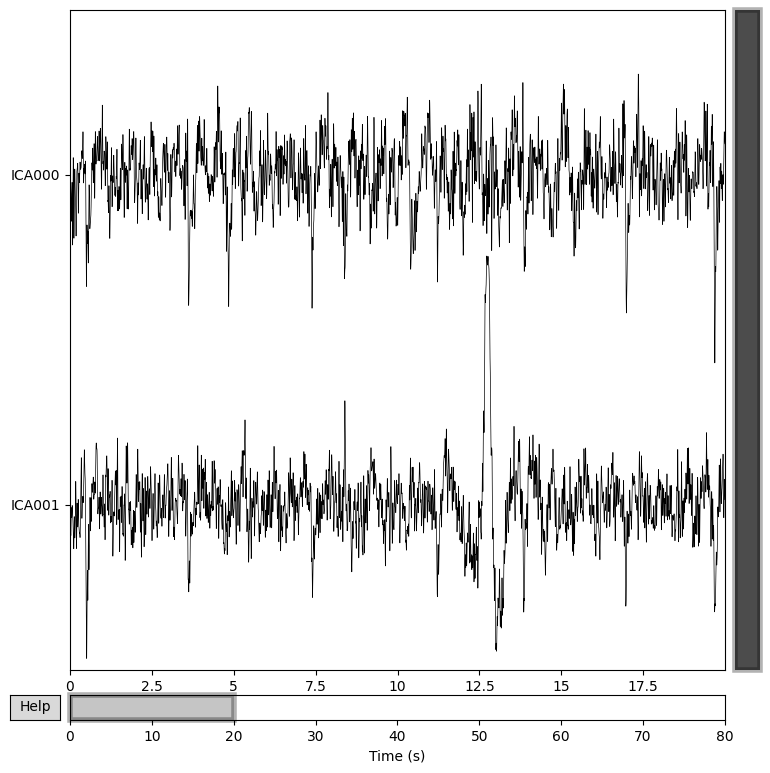

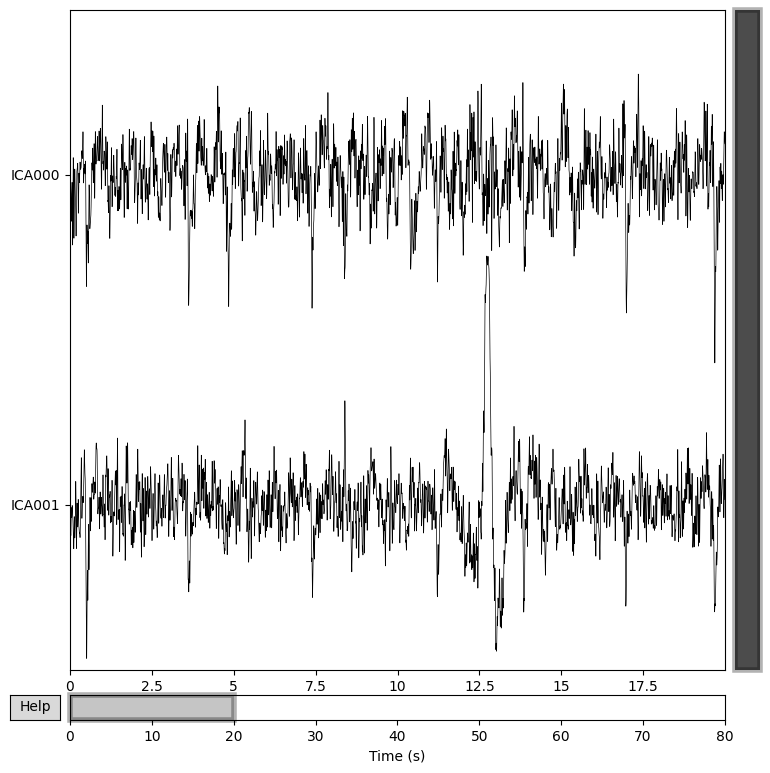

In [96]:
ica.plot_sources(raw)

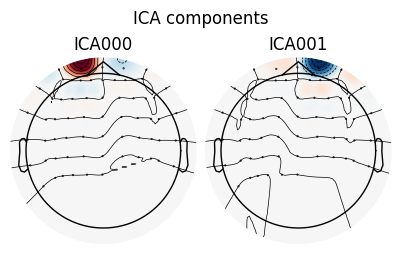

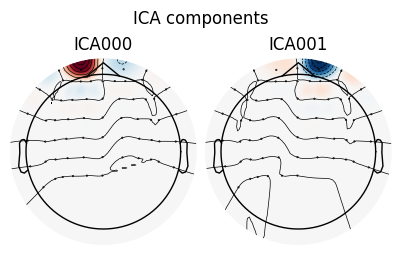

In [82]:
ica.plot_components()

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


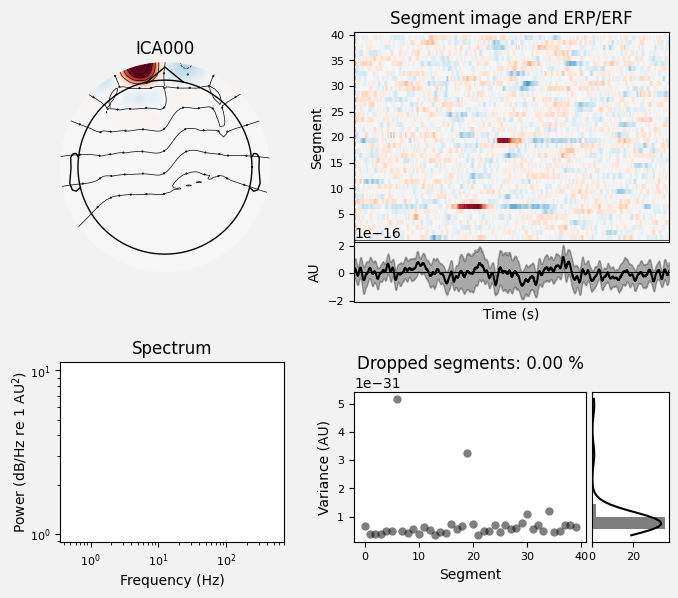

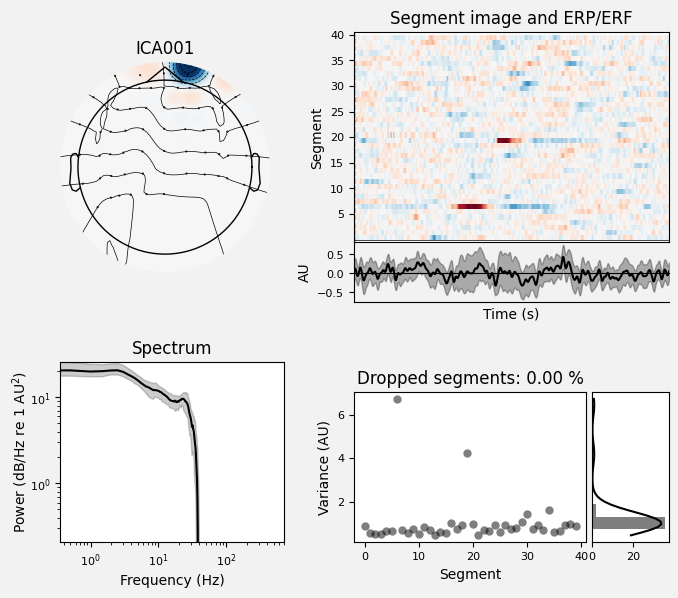

Applying ICA to Raw instance
    Transforming to ICA space (2 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (2 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components


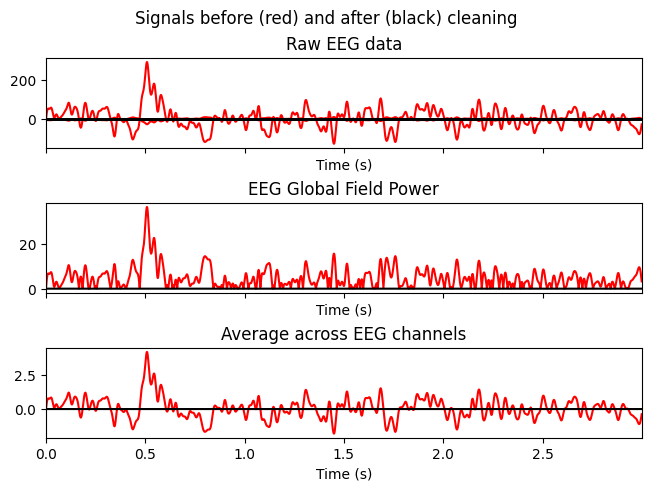

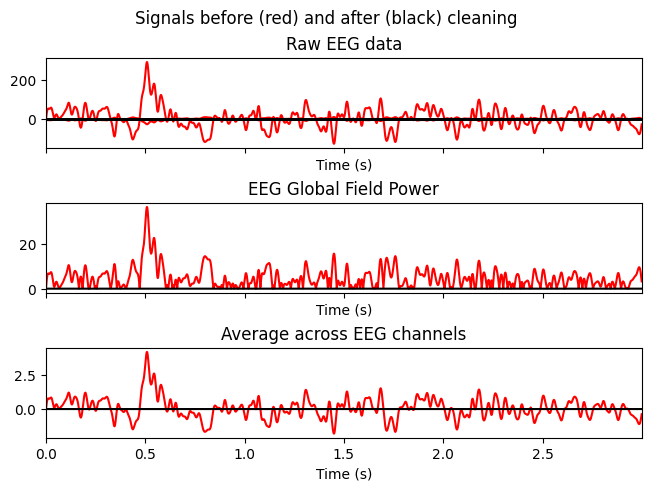

In [100]:
muscle_idx = [0,1]
ica.plot_properties(raw, picks=muscle_idx, log_scale=True)

# first, remove blinks and heartbeat to compare
blink_idx = [0]
heartbeat_idx = [10]
ica.apply(raw, exclude=blink_idx + heartbeat_idx)
ica.plot_overlay(raw, exclude=muscle_idx)

Finally, let's try an automated algorithm to find muscle components
and ensure that it gets the same components we did manually.



Effective window size : 2.048 (s)


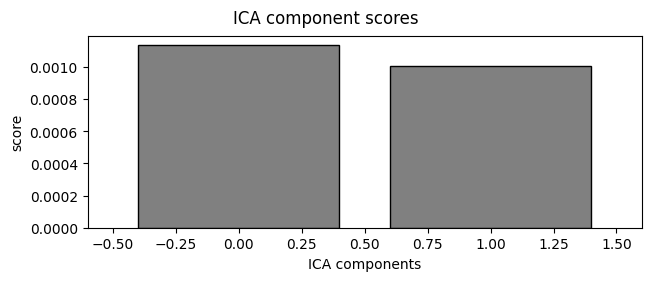

Manually found muscle artifact ICA components:      [0, 1]
Automatically found muscle artifact ICA components: []


In [99]:
muscle_idx_auto, scores = ica.find_bads_muscle(raw)
ica.plot_scores(scores, exclude=muscle_idx_auto)
print(
    f"Manually found muscle artifact ICA components:      {muscle_idx}\n"
    f"Automatically found muscle artifact ICA components: {muscle_idx_auto}"
)

## References

Dhani Dharmaprani, Hoang K. Nguyen, Trent W. Lewis, Dylan DeLosAngeles, John O. Willoughby, and Kenneth J. Pope. A comparison of independent component analysis algorithms and measures to discriminate between EEG and artifact components. In 2016 38th Annual International Conference of the IEEE Engineering in Medicine and Biology Society (EMBC), 825–828. Orlando, FL, USA, 2016. IEEE. doi:10.1109/EMBC.2016.7590828.

